## 서울시 상권 데이터 분석

### 학습 목표

- CSV 파일을 불러와서 데이터를 살펴본다
- 데이터를 원하는 조건으로 걸러내고 집계한다
- 그래프를 그려서 데이터를 눈으로 확인한다

> 파일: `서울상권.csv` (같은 폴더 안에 있어야 합니다)
> 라이브러리: pandas, matplotlib, seaborn

In [1]:
import pandas as pd          
import matplotlib.pyplot as plt   
import seaborn as sns        

In [2]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

``` python
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트
# matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac 사용자는 이 줄 사용
matplotlib.rcParams['axes.unicode_minus'] = False     # 마이너스 부호 깨짐 방지
```

---

## PART 2. 데이터 불러오기

### CSV 파일이란?

> CSV = **C**omma-**S**eparated **V**alues (쉼표로 구분된 값)

### DataFrame 이란?

> pandas에서 표(테이블) 형태의 데이터를 **DataFrame** 이라고 부릅니다.
> - **행(row)**: 하나의 상가·업소 정보
> - **열(column)**: 상호명, 업종 등 항목
> - **인덱스(index)**: 행 번호 (0부터 시작)

In [3]:
df1 = pd.read_csv('서울상권.csv')

In [4]:
df = df1.copy()    

---

## PART 3. 데이터 살펴보기 (기본 탐색)

> 데이터를 받으면 제일 먼저 **어떻게 생긴 데이터인지** 파악해야 합니다.  

### 탐색 명령어 모음

| 명령어 | 의미 |
|--------|------|
| `df.head()` | 앞에서 5행 보기 |
| `df.tail()` | 뒤에서 5행 보기 |
| `df.shape` | (행 수, 열 수) 확인 |
| `df.columns` | 전체 컬럼명 목록 |
| `df.info()` | 컬럼별 타입과 결측치 요약 |
| `df.describe()` | 숫자 컬럼의 통계 요약 | # include='all'

In [5]:
df.head(3)

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
0,MA010120220804265295,60계치킨암사,선사점,음식,기타 간이,치킨,서울특별시,강동구,암사2동,서울특별시 강동구 상암로3길 8,5241,1,127.126859,37.550810
1,MA010120220809658173,성심인력공사,NaN,시설관리·임대,고용 알선,고용 알선업,서울특별시,용산구,남영동,서울특별시 용산구 한강대로 385,4320,NaN,126.972240,37.552803
2,MA010120220808205276,칸토빈,NaN,음식,비알코올,카페,서울특별시,강서구,공항동,서울특별시 강서구 방화동로 30,7619,1,126.810493,37.563548


In [6]:
df.shape

(534978, 14)

In [7]:
df.describe()

,신우편번호,경도,위도
count,534978.000000,534978.000000,534978.000000
mean,5344.210325,126.993058,37.540650
std,2086.710363,0.082605,0.047720
min,1000.000000,126.768186,37.430456
25%,3785.000000,126.922493,37.501818
50%,5565.000000,127.010064,37.536579
75%,6964.000000,127.052791,37.568572
max,8866.000000,127.182653,37.692604


In [8]:
df.describe(include='all')

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
count,534978,534978,47936,534978,534978,534978,534978,534978,534978,534978,534978.000000,346988,534978.000000,534978.000000
unique,534978,425063,858,10,75,247,1,25,427,156448,NaN,201,NaN,NaN
top,MA010120220804265295,업소명없음,코리아,음식,한식,백반/한정식,서울특별시,강남구,역삼1동,서울특별시 송파구 충민로 66,NaN,1,NaN,NaN
freq,1,717,5812,135884,50770,26376,534978,64123,13380,1159,NaN,175319,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5344.210325,NaN,126.993058,37.540650
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2086.710363,NaN,0.082605,0.047720
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000.000000,NaN,126.768186,37.430456
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3785.000000,NaN,126.922493,37.501818
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5565.000000,NaN,127.010064,37.536579
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6964.000000,NaN,127.052791,37.568572


In [9]:
df.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', '시도명',
       '시군구명', '행정동명', '도로명주소', '신우편번호', '층정보', '경도', '위도'],
      dtype='object')

---

## PART 4. 필요한 컬럼만 골라서 사용하기

> 모든 컬럼 전부를 다 쓸 필요는 없습니다.  
> 분석 목적에 맞는 컬럼만 골라서 쓰면 코드가 훨씬 간단해집니다!

### 컬럼 선택 방법

```python

1) 컬럼 1개 선택 → Series 반환
df['컬럼명']

2) 컬럼 여러 개 선택 → DataFrame 반환
df[['컬럼명1', '컬럼명2', '컬럼명3']]
```

> **Series**: 1차원 데이터 (컬럼 1개만 뽑았을 때)  
> **DataFrame**: 2차원 데이터 (컬럼 여러 개)

#### 컬럼 1개 선택 (Series) 
> df['컬럼명'] → 해당 컬럼의 값들을 Series로 반환

In [10]:
df['상권업종대분류명']

0              음식
1         시설관리·임대
2              음식
3          예술·스포츠
4              소매
           ...   
534973         소매
534974         음식
534975         음식
534976         음식
534977         소매
Name: 상권업종대분류명, Length: 534978, dtype: object

#### 컬럼 여러 개 선택 (DataFrame) 
> 바깥쪽 [    ] 는 인덱싱, 안쪽 [      ] 는 리스트  → df[리스트] 형태

In [11]:
df[[  '상권업종대분류명', '상권업종중분류명', '상권업종소분류명'      ]]

,상권업종대분류명,상권업종중분류명,상권업종소분류명
0,음식,기타 간이,치킨
1,시설관리·임대,고용 알선,고용 알선업
2,음식,비알코올,카페
3,예술·스포츠,유원지·오락,노래방
4,소매,시계·귀금속 소매,시계/귀금속 소매업
...,...,...,...
534973,소매,기타 상품 소매,그 외 기타 상품 전문 소매업
534974,음식,한식,곱창 전골/구이
534975,음식,한식,국/탕/찌개류
534976,음식,비알코올,카페


---

## PART 5. 빠진 값(결측치) 처리하기

### 결측치(Missing Value)란?

> 데이터가 **비어있는 경우**를 결측치라고 합니다.  
> `NaN` (Not a Number) 으로 표시됩니다.

### 왜 처리해야 할까요?

- 결측치가 있으면 계산이 틀려질 수 있고 오류가 날 수 있습니다

### 결측치 처리 방법

| 방법 | 코드 | 언제 쓰나 |
|------|------|----------|
| 확인 | `df.isnull().sum()` | 결측치가 몇 개인지 확인 |
| 제거 | `df.dropna()` | 결측치 있는 행 통째로 제거 |
|      | `df.dropna(subset=['컬럼명'])` | 해당 컬럼에 결측치가 있는 행만 제거 |
| 채우기 | `df.fillna(값)` | 결측치를 특정 값으로 채우기 |

In [12]:
df.isnull().sum()

상가업소번호           0
상호명              0
지점명         487042
상권업종대분류명         0
상권업종중분류명         0
상권업종소분류명         0
시도명              0
시군구명             0
행정동명             0
도로명주소            0
신우편번호            0
층정보         187990
경도               0
위도               0
dtype: int64

---

## PART 6. 조건에 맞는 데이터만 골라내기 (필터링)

> 전체 데이터 중 원하는 행만 골라내는 것을 **필터링** 이라고 합니다.  

### 기본 문법

```python
df[조건식]
```

### 비교 연산자

> ==, !=, >, >=, <, <=

### 다중 조건

| 기호 | 의미 | 예시 |
|------|------|------|
| `&` | AND (둘 다 참) | `(조건1) & (조건2)` |
| `\|` | OR (하나라도 참) | `(조건1) \| (조건2)` |
| `~` | NOT (반대) | `~조건` |

> **주의**: 다중 조건은 반드시 각 조건을 `()` 괄호로 감싸야 합니다!

In [13]:
df.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', '시도명',
       '시군구명', '행정동명', '도로명주소', '신우편번호', '층정보', '경도', '위도'],
      dtype='object')

문제 1 : '강남구'인 데이터만 선택

In [14]:
df[ df['시군구명'] == '강남구']

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
11,MA010120220804484713,세마스포츠마케팅,NaN,시설관리·임대,기타 사업 서비스,전시/컨벤션/행사 대행 서비스업,서울특별시,강남구,역삼1동,서울특별시 강남구 테헤란로25길 47,6126,NaN,127.034404,37.503571
16,MA010120220804119412,솔잎약국,NaN,소매,의약·화장품 소매,약국,서울특별시,강남구,개포3동,서울특별시 강남구 개포로 615,6335,NaN,127.075593,37.492659
45,MA010120220808263588,강남주얼리창업아카데미,NaN,과학·기술,본사·경영 컨설팅,경영 컨설팅업,서울특별시,강남구,압구정동,서울특별시 강남구 압구정로30길 60,6025,4,127.028858,37.523449
63,MA010120220810251143,타카라,NaN,음식,일식,일식 회/초밥,서울특별시,강남구,압구정동,서울특별시 강남구 압구정로48길 15,6018,1,127.037243,37.527528
65,MA010120220806625053,에이에이치이엔씨,NaN,과학·기술,기술 서비스,건축 설계 및 관련 서비스업,서울특별시,강남구,세곡동,서울특별시 강남구 자곡로 174-10,6373,NaN,127.103010,37.472671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534904,MA0106202511A0047254,휴먼메이드압구정,NaN,소매,섬유·의복·신발 소매,기타 의류 소매업,서울특별시,강남구,압구정동,서울특별시 강남구 선릉로157길 20-8,6018,NaN,127.038543,37.526617
534914,MA0106202511A0652755,앵콜노래연습장,NaN,예술·스포츠,유원지·오락,노래방,서울특별시,강남구,역삼1동,서울특별시 강남구 봉은사로2길 24,6123,NaN,127.025887,37.503087
534923,MA0106202511A0498693,윤대감빈대떡,NaN,음식,한식,전/부침개,서울특별시,강남구,역삼1동,서울특별시 강남구 강남대로84길 15,6232,NaN,127.029764,37.497013
534929,MA0106202511A1958658,미소담은,NaN,소매,의약·화장품 소매,화장품 소매업,서울특별시,강남구,청담동,서울특별시 강남구 도산대로81길 23,6011,NaN,127.047231,37.525911


문제 2: 상권업종대분류명이 '음식' 인 데이터만 선택

In [16]:
df[ df['상권업종대분류명'] =='음식']

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
0,MA010120220804265295,60계치킨암사,선사점,음식,기타 간이,치킨,서울특별시,강동구,암사2동,서울특별시 강동구 상암로3길 8,5241,1,127.126859,37.550810
2,MA010120220808205276,칸토빈,NaN,음식,비알코올,카페,서울특별시,강서구,공항동,서울특별시 강서구 방화동로 30,7619,1,126.810493,37.563548
8,MA010120220809640417,솜노래팡팡,NaN,음식,주점,요리 주점,서울특별시,서초구,서초3동,서울특별시 서초구 서초대로50길 75,6650,1,127.013852,37.489862
15,MA010120220812811919,읏듬돈생삼겹살,NaN,음식,한식,돼지고기 구이/찜,서울특별시,성북구,석관동,서울특별시 성북구 화랑로40길 43,2781,1,127.064015,37.613579
36,MA010120220809620318,동원기사식당,NaN,음식,한식,백반/한정식,서울특별시,양천구,신정7동,서울특별시 양천구 목동남로 64-1,8101,1,126.866492,37.509645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534971,MA0106202511A0686689,오부찌,NaN,음식,한식,백반/한정식,서울특별시,송파구,문정2동,서울특별시 송파구 송파대로 167,5855,NaN,127.120755,37.484557
534972,MA0106202511A1878996,생각과생각사이,NaN,음식,한식,백반/한정식,서울특별시,용산구,용산2가동,서울특별시 용산구 신흥로 11,4338,NaN,126.986332,37.539624
534974,MA0106202511A2270156,연막창건대,직영점,음식,한식,곱창 전골/구이,서울특별시,광진구,화양동,서울특별시 광진구 동일로24길 101,5016,NaN,127.070563,37.542406
534975,MA0106202511A0034578,하루곰탕,NaN,음식,한식,국/탕/찌개류,서울특별시,동대문구,장안2동,서울특별시 동대문구 사가정로25길 21,2516,NaN,127.070371,37.579807


음식에서 상권업종중분류명 검색

<Axes: xlabel='상권업종중분류명'>

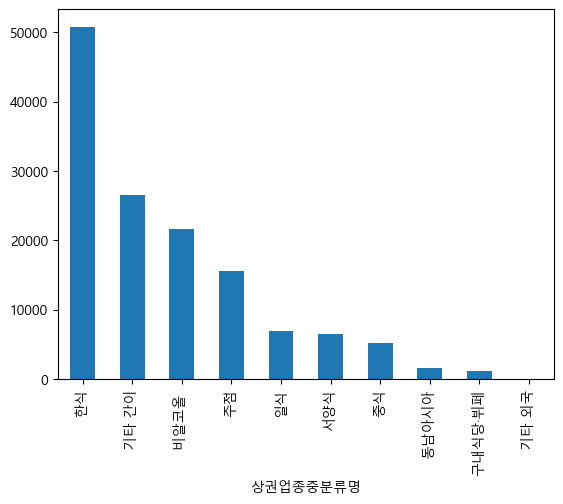

In [17]:
df[ df['상권업종대분류명'] =='음식']['상권업종중분류명'].value_counts().plot(kind='bar')

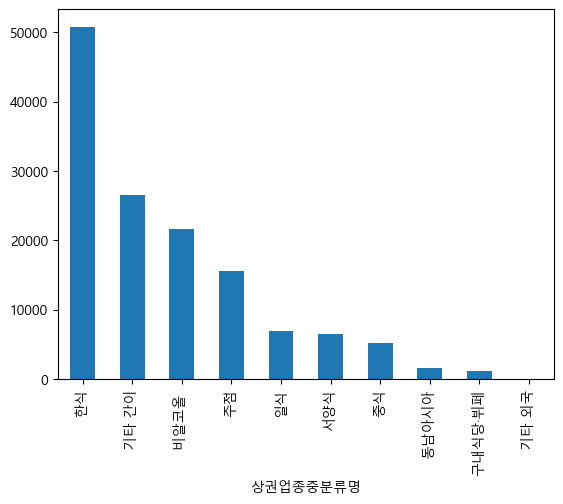

In [18]:
df_food =df[ df['상권업종대분류명'] =='음식']
df_food['상권업종중분류명'].value_counts().plot(kind='bar')
plt.show()

문제 2-3: 상권업종중분류명이 한식인 경우 상권업종소분류명 ?

In [19]:
df[ df['상권업종중분류명']=='한식' ]['상권업종소분류명'].value_counts()

상권업종소분류명
백반/한정식         26376
돼지고기 구이/찜       7682
국/탕/찌개류         4571
국수/칼국수          2843
횟집              1955
해산물 구이/찜        1693
곱창 전골/구이        1271
닭/오리고기 구이/찜     1195
족발/보쌈           1156
소고기 구이/찜         901
냉면/밀면            584
기타 한식 음식점        272
전/부침개            189
복 요리 전문           82
Name: count, dtype: int64

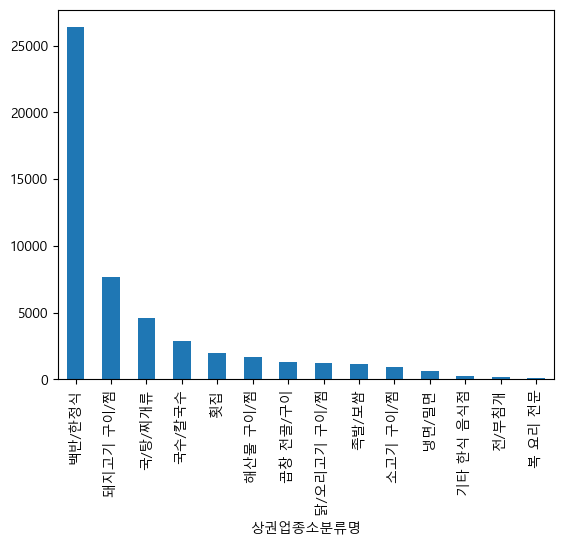

In [20]:
df[ df['상권업종중분류명']=='한식' ]['상권업종소분류명'].value_counts().plot(kind='bar')
plt.xticks(rotation=90)
plt.show()

문제 3: 상호명에 '치킨' 이 들어가는 업소 찾기

In [22]:
df[df['상호명'].str.contains('치킨') ]

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
0,MA010120220804265295,60계치킨암사,선사점,음식,기타 간이,치킨,서울특별시,강동구,암사2동,서울특별시 강동구 상암로3길 8,5241,1,127.126859,37.550810
435,MA010120220813331151,굽네치킨마포도화점,NaN,음식,기타 간이,치킨,서울특별시,마포구,도화동,서울특별시 마포구 도화4길 23,4169,1,126.951164,37.540885
556,MA010120220813742641,아이러브피자&치킨,NaN,음식,기타 간이,치킨,서울특별시,은평구,신사1동,서울특별시 은평구 증산로21길 10,3450,1,126.913794,37.595996
577,MA010120220800265091,치킨뱅이,NaN,음식,기타 간이,치킨,서울특별시,용산구,남영동,서울특별시 용산구 한강대로 399,4320,NaN,126.972352,37.553957
1200,MA010120220811798444,치킨을사랑한떡볶이,강동점,음식,기타 간이,김밥/만두/분식,서울특별시,강동구,성내3동,서울특별시 강동구 양재대로87길 5,5405,2,127.134588,37.525285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534513,MA0106202511A1947495,자담치킨,금천구청역점,음식,기타 간이,치킨,서울특별시,금천구,독산1동,서울특별시 금천구 시흥대로 291,8608,NaN,126.897244,37.460553
534569,MA0106202511A1415825,교촌치킨,고척점,음식,기타 간이,치킨,서울특별시,구로구,고척2동,서울특별시 구로구 경인로33길 89,8235,NaN,126.850435,37.501787
534732,MA0106202511A2381493,파자나라치킨공주,목동점,음식,기타 간이,치킨,서울특별시,양천구,목4동,서울특별시 양천구 목동중앙로3길 59,7960,NaN,126.867857,37.537497
534871,MA0106202511A0569154,처갓집양념치킨북,아현점,음식,기타 간이,치킨,서울특별시,서대문구,충현동,서울특별시 서대문구 경기대로9길 81,3752,NaN,126.959705,37.564423


문제 4: 종로구, 중구, 동대문구 세 곳 중 하나인 데이터만 선택

In [23]:
df[ df['시군구명'].isin( [  '종로구', '중구', '동대문구' ] )]

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
4,MA010120220810170381,금빛주얼리,NaN,소매,시계·귀금속 소매,시계/귀금속 소매업,서울특별시,종로구,종로1.2.3.4가동,서울특별시 종로구 돈화문로10길 2,3138,1,126.991861,37.572331
14,MA010120220803494326,DGI,NaN,소매,섬유·의복·신발 소매,액세서리/잡화 소매업,서울특별시,중구,회현동,서울특별시 중구 소공로 58,4535,1,126.981846,37.560662
18,MA010120220803750708,우성그린공인중개사사무소,NaN,부동산,부동산 서비스,부동산 중개/대리업,서울특별시,동대문구,답십리2동,서울특별시 동대문구 한천로 145,2535,1,127.066710,37.574006
22,MA010120220813245508,요꼬양말,NaN,소매,섬유·의복·신발 소매,유아용 의류 소매업,서울특별시,중구,회현동,서울특별시 중구 남대문시장8길 13,4529,NaN,126.978643,37.559869
28,MA010120220800002811,PRO.COM,NaN,수리·개인,통신장비 수리,핸드폰/통신장비 수리업,서울특별시,종로구,종로1.2.3.4가동,서울특별시 종로구 창경궁로 109,3137,3,126.997079,37.572349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534955,MA0106202511A0356826,아트모아,NaN,소매,섬유·의복·신발 소매,가발 소매업,서울특별시,중구,광희동,서울특별시 중구 청계천로 274,4563,NaN,127.008048,37.569430
534966,MA0106202511A0711978,몽중헌,광화문,음식,중식,중국집,서울특별시,종로구,사직동,서울특별시 종로구 새문안로5길 31,3173,NaN,126.974360,37.572977
534969,MA0106202511A1075943,곧은,NaN,음식,한식,백반/한정식,서울특별시,종로구,종로1.2.3.4가동,서울특별시 종로구 삼일대로17길 51,3189,NaN,126.984674,37.569078
534975,MA0106202511A0034578,하루곰탕,NaN,음식,한식,국/탕/찌개류,서울특별시,동대문구,장안2동,서울특별시 동대문구 사가정로25길 21,2516,NaN,127.070371,37.579807


문제 5: 강남구의 음식 업종인 상가 찾기

In [24]:
df[ (df['시군구명'] =='강남구')  &  ( df['상권업종대분류명'] == '음식')]

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
63,MA010120220810251143,타카라,NaN,음식,일식,일식 회/초밥,서울특별시,강남구,압구정동,서울특별시 강남구 압구정로48길 15,6018,1,127.037243,37.527528
476,MA010120220803319560,터닝포인트,NaN,음식,기타 간이,피자,서울특별시,강남구,역삼2동,서울특별시 강남구 테헤란로44길 8,6210,5,127.044446,37.502333
562,MA010120220800606553,에이치,NaN,음식,서양식,경양식,서울특별시,강남구,논현2동,서울특별시 강남구 봉은사로 319,6103,1,127.041826,37.509939
779,MA010120220803390251,라플란드,NaN,음식,서양식,경양식,서울특별시,강남구,삼성2동,서울특별시 강남구 봉은사로63길 11,6097,4,127.046895,37.512135
819,MA010120220813266322,훈,NaN,음식,일식,일식 회/초밥,서울특별시,강남구,대치2동,서울특별시 강남구 삼성로84길 28,6184,1,127.059840,37.505759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534862,MA0106202511A1601966,까만미소의하루,NaN,음식,비알코올,카페,서울특별시,강남구,역삼1동,서울특별시 강남구 테헤란로20길 20,6235,NaN,127.034514,37.498363
534870,MA0106202511A1128607,탉,NaN,음식,한식,백반/한정식,서울특별시,강남구,압구정동,서울특별시 강남구 언주로168길 24,6020,NaN,127.035545,37.525915
534885,MA0106202511A1654833,마이니치라멘,선정릉점,음식,일식,일식 면 요리,서울특별시,강남구,삼성2동,서울특별시 강남구 봉은사로63길 7,6097,NaN,127.046962,37.511937
534888,MA0106202511A0145239,에스에이치케이인터내셔널,NaN,음식,서양식,경양식,서울특별시,강남구,도곡2동,서울특별시 강남구 논현로28길 14,6302,NaN,127.043970,37.482709


In [25]:
cond1 =  df['시군구명'] =='강남구'

In [26]:
cond2 =  df['상권업종대분류명'] == '음식'

In [27]:
df[ cond1   &  cond2    ]

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
63,MA010120220810251143,타카라,NaN,음식,일식,일식 회/초밥,서울특별시,강남구,압구정동,서울특별시 강남구 압구정로48길 15,6018,1,127.037243,37.527528
476,MA010120220803319560,터닝포인트,NaN,음식,기타 간이,피자,서울특별시,강남구,역삼2동,서울특별시 강남구 테헤란로44길 8,6210,5,127.044446,37.502333
562,MA010120220800606553,에이치,NaN,음식,서양식,경양식,서울특별시,강남구,논현2동,서울특별시 강남구 봉은사로 319,6103,1,127.041826,37.509939
779,MA010120220803390251,라플란드,NaN,음식,서양식,경양식,서울특별시,강남구,삼성2동,서울특별시 강남구 봉은사로63길 11,6097,4,127.046895,37.512135
819,MA010120220813266322,훈,NaN,음식,일식,일식 회/초밥,서울특별시,강남구,대치2동,서울특별시 강남구 삼성로84길 28,6184,1,127.059840,37.505759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534862,MA0106202511A1601966,까만미소의하루,NaN,음식,비알코올,카페,서울특별시,강남구,역삼1동,서울특별시 강남구 테헤란로20길 20,6235,NaN,127.034514,37.498363
534870,MA0106202511A1128607,탉,NaN,음식,한식,백반/한정식,서울특별시,강남구,압구정동,서울특별시 강남구 언주로168길 24,6020,NaN,127.035545,37.525915
534885,MA0106202511A1654833,마이니치라멘,선정릉점,음식,일식,일식 면 요리,서울특별시,강남구,삼성2동,서울특별시 강남구 봉은사로63길 7,6097,NaN,127.046962,37.511937
534888,MA0106202511A0145239,에스에이치케이인터내셔널,NaN,음식,서양식,경양식,서울특별시,강남구,도곡2동,서울특별시 강남구 논현로28길 14,6302,NaN,127.043970,37.482709


---

## PART 7. 데이터 집계하기

> **집계**란 데이터를 요약하는 것입니다.  
> '시군구별로 상가가 몇 개인지', '업종별로 몇 개인지' 등과 같은 것을 구하는 과정입니다.

### 주요 집계 함수

| 함수 | 설명 | 예시 |
|------|------|------|
| `value_counts()` | 각 값의 등장 횟수 세기 | `df['상권업종대분류명'].value_counts()` |
| `groupby()` | 그룹별로 묶어서 집계 | `df.groupby('시군구명')['경도'].mean()` |
| `nunique()` | 고유한 값의 수 | `df['상권업종중분류명'].nunique()` |

문제 1: 업종대분류명 별로 상가 갯수

In [28]:
df.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', '시도명',
       '시군구명', '행정동명', '도로명주소', '신우편번호', '층정보', '경도', '위도'],
      dtype='object')

In [29]:
df['상권업종대분류명'].unique()

array(['음식', '시설관리·임대', '예술·스포츠', '소매', '부동산', '과학·기술', '수리·개인', '보건의료',
       '숙박', '교육'], dtype=object)

In [30]:
df['상권업종대분류명'].nunique()

10

In [31]:
df['상권업종대분류명'].value_counts()

상권업종대분류명
음식         135884
소매         111632
과학·기술       93261
수리·개인       51626
교육          45158
부동산         25059
시설관리·임대     24231
예술·스포츠      20446
보건의료        18840
숙박           8841
Name: count, dtype: int64

문제 2: 시군구명 별로 상가 갯수

In [32]:
df['시군구명'].unique()

array(['강동구', '용산구', '강서구', '노원구', '종로구', '마포구', '관악구', '서초구', '송파구',
       '광진구', '강남구', '은평구', '중구', '성북구', '동작구', '동대문구', '성동구', '도봉구',
       '영등포구', '구로구', '중랑구', '양천구', '서대문구', '강북구', '금천구'], dtype=object)

In [33]:
df['시군구명'].nunique()

25

In [34]:
df['시군구명'].value_counts()

시군구명
강남구     64123
서초구     38892
송파구     33559
마포구     30488
영등포구    28439
강서구     26028
중구      24117
종로구     20804
관악구     19283
강동구     19046
광진구     18016
구로구     17921
금천구     17734
성동구     17221
동대문구    16673
은평구     15914
용산구     15701
양천구     15626
성북구     15535
노원구     15416
중랑구     14571
동작구     13724
서대문구    13634
강북구     12174
도봉구     10339
Name: count, dtype: int64

<Axes: xlabel='시군구명'>

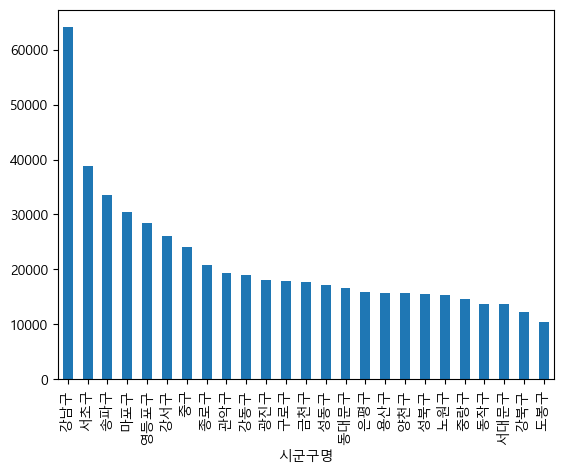

In [35]:
df.groupby('시군구명').size().sort_values(ascending=False).plot(kind='bar')

In [36]:
df.groupby('시군구명').size().index

Index(['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구',
       '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구', '영등포구',
       '용산구', '은평구', '종로구', '중구', '중랑구'],
      dtype='object', name='시군구명')

In [37]:
df.groupby('시군구명').size().values

array([64123, 19046, 12174, 26028, 19283, 18016, 17921, 17734, 15416,
       10339, 16673, 13724, 30488, 13634, 38892, 17221, 15535, 33559,
       15626, 28439, 15701, 15914, 20804, 24117, 14571])

In [38]:
df.groupby('시군구명').size()

시군구명
강남구     64123
강동구     19046
강북구     12174
강서구     26028
관악구     19283
광진구     18016
구로구     17921
금천구     17734
노원구     15416
도봉구     10339
동대문구    16673
동작구     13724
마포구     30488
서대문구    13634
서초구     38892
성동구     17221
성북구     15535
송파구     33559
양천구     15626
영등포구    28439
용산구     15701
은평구     15914
종로구     20804
중구      24117
중랑구     14571
dtype: int64

In [39]:
df.groupby('시군구명').size().reset_index()

,시군구명,0
0,강남구,64123
1,강동구,19046
2,강북구,12174
3,강서구,26028
4,관악구,19283
5,광진구,18016
6,구로구,17921
7,금천구,17734
8,노원구,15416
9,도봉구,10339


In [40]:
df.groupby('시군구명').size().reset_index(name='상가수')

,시군구명,상가수
0,강남구,64123
1,강동구,19046
2,강북구,12174
3,강서구,26028
4,관악구,19283
5,광진구,18016
6,구로구,17921
7,금천구,17734
8,노원구,15416
9,도봉구,10339


문제 3: 시군구별 업종소분류명에 따른 상가의 갯수는?

In [41]:
df.groupby('시군구명'     )['상권업종소분류명'].count()

시군구명
강남구     64123
강동구     19046
강북구     12174
강서구     26028
관악구     19283
광진구     18016
구로구     17921
금천구     17734
노원구     15416
도봉구     10339
동대문구    16673
동작구     13724
마포구     30488
서대문구    13634
서초구     38892
성동구     17221
성북구     15535
송파구     33559
양천구     15626
영등포구    28439
용산구     15701
은평구     15914
종로구     20804
중구      24117
중랑구     14571
Name: 상권업종소분류명, dtype: int64

In [42]:
df.groupby('시군구명'     )['상호명'].count()

시군구명
강남구     64123
강동구     19046
강북구     12174
강서구     26028
관악구     19283
광진구     18016
구로구     17921
금천구     17734
노원구     15416
도봉구     10339
동대문구    16673
동작구     13724
마포구     30488
서대문구    13634
서초구     38892
성동구     17221
성북구     15535
송파구     33559
양천구     15626
영등포구    28439
용산구     15701
은평구     15914
종로구     20804
중구      24117
중랑구     14571
Name: 상호명, dtype: int64

In [43]:
df.groupby('시군구명'     ).size()

시군구명
강남구     64123
강동구     19046
강북구     12174
강서구     26028
관악구     19283
광진구     18016
구로구     17921
금천구     17734
노원구     15416
도봉구     10339
동대문구    16673
동작구     13724
마포구     30488
서대문구    13634
서초구     38892
성동구     17221
성북구     15535
송파구     33559
양천구     15626
영등포구    28439
용산구     15701
은평구     15914
종로구     20804
중구      24117
중랑구     14571
dtype: int64

In [44]:
df['시군구명'].value_counts()

시군구명
강남구     64123
서초구     38892
송파구     33559
마포구     30488
영등포구    28439
강서구     26028
중구      24117
종로구     20804
관악구     19283
강동구     19046
광진구     18016
구로구     17921
금천구     17734
성동구     17221
동대문구    16673
은평구     15914
용산구     15701
양천구     15626
성북구     15535
노원구     15416
중랑구     14571
동작구     13724
서대문구    13634
강북구     12174
도봉구     10339
Name: count, dtype: int64

#### 두 컬럼의 교차표 만들기 
>  행과 열을 교차해서 개수 세기 

In [45]:
pd.crosstab(df['시군구명'] , df['상권업종대분류명']   )

상권업종대분류명,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식
시군구명,,,,,,,,,,
강남구,18854,6219,3067,3665,9869,4681,511,3132,1779,12346
강동구,1681,2008,882,1121,4232,2310,276,724,875,4937
강북구,980,764,477,532,2860,1683,183,434,649,3612
강서구,3683,2273,958,1280,5117,3203,261,1283,1145,6825
관악구,1878,1567,687,908,3845,2491,630,713,1091,5473
광진구,2088,1389,592,868,4073,2077,302,784,918,4925
구로구,2926,1319,563,704,4104,1849,228,835,822,4571
금천구,5814,835,361,737,3312,1432,122,984,545,3592
노원구,1022,2022,724,581,3529,1804,103,444,860,4327


In [46]:
df['시군구명'].value_counts().head(5)

시군구명
강남구     64123
서초구     38892
송파구     33559
마포구     30488
영등포구    28439
Name: count, dtype: int64

In [47]:
df['시군구명'].value_counts().head(5).index

Index(['강남구', '서초구', '송파구', '마포구', '영등포구'], dtype='object', name='시군구명')

In [51]:
top_5 = df['시군구명'].value_counts().head(5).index

In [52]:
df_top5 = df[ df['시군구명'].isin(top_5)]
df_top5

,상가업소번호,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,도로명주소,신우편번호,층정보,경도,위도
5,MA010120220800218616,골든공인중개사사무소,NaN,부동산,부동산 서비스,부동산 중개/대리업,서울특별시,마포구,성산2동,서울특별시 마포구 월드컵로34길 6,3938,NaN,126.903067,37.564570
8,MA010120220809640417,솜노래팡팡,NaN,음식,주점,요리 주점,서울특별시,서초구,서초3동,서울특별시 서초구 서초대로50길 75,6650,1,127.013852,37.489862
9,MA010120220804301582,한양가구갤러리주,NaN,소매,가구 소매,가구 소매업,서울특별시,송파구,잠실3동,서울특별시 송파구 올림픽로 215,5503,NaN,127.095047,37.514007
11,MA010120220804484713,세마스포츠마케팅,NaN,시설관리·임대,기타 사업 서비스,전시/컨벤션/행사 대행 서비스업,서울특별시,강남구,역삼1동,서울특별시 강남구 테헤란로25길 47,6126,NaN,127.034404,37.503571
12,MA010120220800800619,참편한공인중개사사무소,NaN,부동산,부동산 서비스,부동산 중개/대리업,서울특별시,서초구,방배1동,서울특별시 서초구 방배로19길 25,6682,1,126.993691,37.484844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534965,MA0106202511A2156972,체도비책,NaN,과학·기술,기타 전문 과학,번역/통역 서비스업,서울특별시,서초구,방배2동,서울특별시 서초구 방배천로18길 38,6677,NaN,126.984895,37.482581
534970,MA0106202511A0871177,우성카드시스템,NaN,소매,안경·정밀기기 소매,사무기기 소매업,서울특별시,서초구,서초3동,서울특별시 서초구 서초대로46길 99,6650,NaN,127.013479,37.490177
534971,MA0106202511A0686689,오부찌,NaN,음식,한식,백반/한정식,서울특별시,송파구,문정2동,서울특별시 송파구 송파대로 167,5855,NaN,127.120755,37.484557
534973,MA0106202511A1072506,살림,NaN,소매,기타 상품 소매,그 외 기타 상품 전문 소매업,서울특별시,송파구,잠실2동,서울특별시 송파구 올림픽로 119,5501,NaN,127.084186,37.512087


In [53]:
교차표 = pd.crosstab(df_top5['시군구명'], df_top5['상권업종대분류명'] )
교차표

상권업종대분류명,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식
시군구명,,,,,,,,,,
강남구,18854,6219,3067,3665,9869,4681,511,3132,1779,12346
마포구,5704,2634,752,1161,4837,2690,1192,1616,900,9002
서초구,12633,3820,1527,2094,6491,2472,308,1819,1082,6646
송파구,6036,3116,1211,1695,6734,3428,369,1386,1561,8023
영등포구,6196,1813,815,1151,5391,2350,403,1614,1122,7584


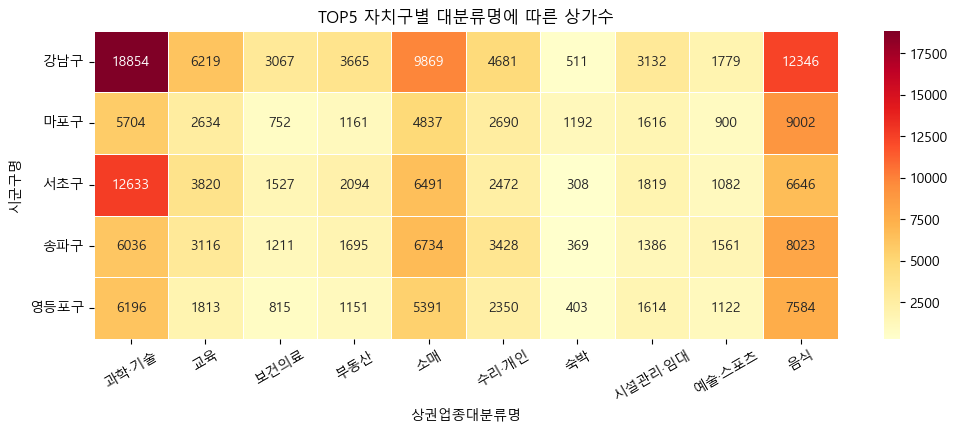

In [54]:
plt.figure(figsize=(12,4))
sns.heatmap(교차표,
            annot=True,        # 셀 안에 숫자 표시 여부 (True/False)
            fmt='.0f',         # 숫자 형식 (소수점 1자리)
            cmap='YlOrRd',     # 색상맵: 노란→주황→빨강
            linewidths=0.5,    # 셀 구분선 두께
            linecolor='white'  # 셀 구분선 색
           )
plt.title('TOP5 자치구별 대분류명에 따른 상가수')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.show()

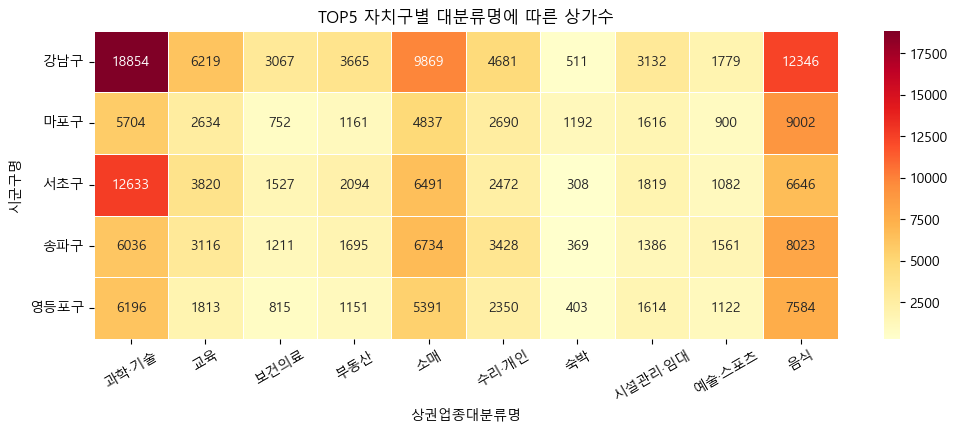

In [55]:
plt.figure(figsize=(12,4))
sns.heatmap(교차표,
            annot=True,        # 셀 안에 숫자 표시 여부 (True/False)
            fmt='.0f',         # 숫자 형식 (소수점 1자리)
            cmap='YlOrRd',     # 색상맵: 노란→주황→빨강
            linewidths=0.5,    # 셀 구분선 두께
            linecolor='white'  # 셀 구분선 색
           )
plt.title('TOP5 자치구별 대분류명에 따른 상가수')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.show()

In [56]:
df.pivot_table(
    values='상호명',
    index='시군구명',
    columns='상권업종대분류명',
    aggfunc='count'
)

상권업종대분류명,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식
시군구명,,,,,,,,,,
강남구,18854,6219,3067,3665,9869,4681,511,3132,1779,12346
강동구,1681,2008,882,1121,4232,2310,276,724,875,4937
강북구,980,764,477,532,2860,1683,183,434,649,3612
강서구,3683,2273,958,1280,5117,3203,261,1283,1145,6825
관악구,1878,1567,687,908,3845,2491,630,713,1091,5473
광진구,2088,1389,592,868,4073,2077,302,784,918,4925
구로구,2926,1319,563,704,4104,1849,228,835,822,4571
금천구,5814,835,361,737,3312,1432,122,984,545,3592
노원구,1022,2022,724,581,3529,1804,103,444,860,4327


In [57]:
df.pivot_table(
    values='상호명',
    index='시군구명',
    columns='상권업종대분류명',
    aggfunc='count'
)

상권업종대분류명,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식
시군구명,,,,,,,,,,
강남구,18854,6219,3067,3665,9869,4681,511,3132,1779,12346
강동구,1681,2008,882,1121,4232,2310,276,724,875,4937
강북구,980,764,477,532,2860,1683,183,434,649,3612
강서구,3683,2273,958,1280,5117,3203,261,1283,1145,6825
관악구,1878,1567,687,908,3845,2491,630,713,1091,5473
광진구,2088,1389,592,868,4073,2077,302,784,918,4925
구로구,2926,1319,563,704,4104,1849,228,835,822,4571
금천구,5814,835,361,737,3312,1432,122,984,545,3592
노원구,1022,2022,724,581,3529,1804,103,444,860,4327


In [58]:
df_top5.pivot_table(
    values='상호명',
    index='시군구명',
    columns='상권업종대분류명',
    aggfunc='count'
)

상권업종대분류명,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식
시군구명,,,,,,,,,,
강남구,18854,6219,3067,3665,9869,4681,511,3132,1779,12346
마포구,5704,2634,752,1161,4837,2690,1192,1616,900,9002
서초구,12633,3820,1527,2094,6491,2472,308,1819,1082,6646
송파구,6036,3116,1211,1695,6734,3428,369,1386,1561,8023
영등포구,6196,1813,815,1151,5391,2350,403,1614,1122,7584


In [59]:
df_top5.pivot_table(
    values='상호명',
    index='시군구명',
    columns='상권업종대분류명',
    aggfunc='count'
)

상권업종대분류명,과학·기술,교육,보건의료,부동산,소매,수리·개인,숙박,시설관리·임대,예술·스포츠,음식
시군구명,,,,,,,,,,
강남구,18854,6219,3067,3665,9869,4681,511,3132,1779,12346
마포구,5704,2634,752,1161,4837,2690,1192,1616,900,9002
서초구,12633,3820,1527,2094,6491,2472,308,1819,1082,6646
송파구,6036,3116,1211,1695,6734,3428,369,1386,1561,8023
영등포구,6196,1813,815,1151,5391,2350,403,1614,1122,7584


---

## PART 8. 데이터 시각화하기

> **시각화**란 데이터를 그래프나 차트로 표현하는 것입니다.  
> 숫자로만 보면 이해하기 어려운 패턴을 눈으로 바로 확인할 수 있습니다!

### 그래프 종류 선택 기준

| 그래프 | 언제 사용? | 예시 |
|--------|-----------|------|
| 막대 그래프 | 항목 간 크기 비교 | 구별 상가 수 비교 |
| 파이 차트 | 전체에서 비율 | 업종 비율 |
| 히스토그램 | 분포 확인 | 상가 수 분포 |
| 산점도 | 두 변수의 관계 | 위도 vs 경도 |

1. **pandas `.plot()`** : 가장 간단, Series, DataFrame에 바로 적용
2. **seaborn** : 예쁜 통계 그래프
3. **matplotlib.pyplot `plt`** : 세밀한 설정 가능

문제 1: 상권업종대분류명별 상가 수 

In [60]:
df['상권업종대분류명'].value_counts().index

Index(['음식', '소매', '과학·기술', '수리·개인', '교육', '부동산', '시설관리·임대', '예술·스포츠', '보건의료',
       '숙박'],
      dtype='object', name='상권업종대분류명')

<Axes: ylabel='상권업종대분류명'>

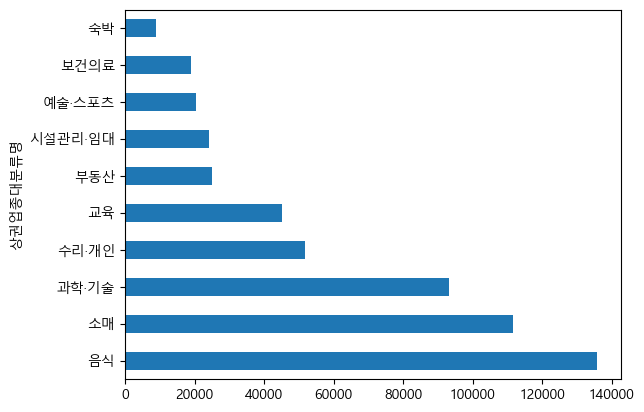

In [61]:
df['상권업종대분류명'].value_counts().plot(kind='barh')

<Axes: xlabel='count', ylabel='상권업종대분류명'>

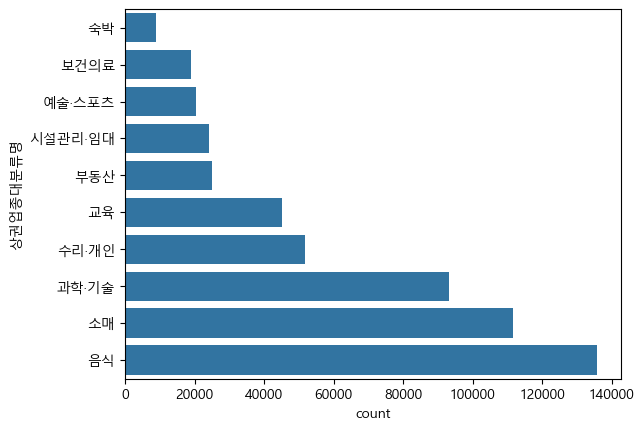

In [62]:
sns.countplot(data=df, y='상권업종대분류명',
              order=df['상권업종대분류명'].value_counts().sort_values().index )

<Axes: xlabel='count', ylabel='상권업종대분류명'>

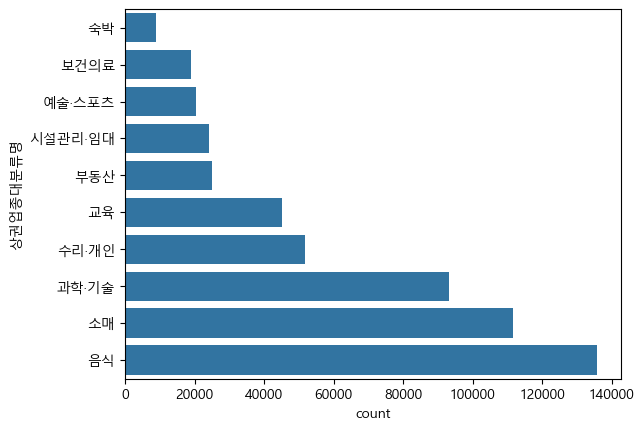

In [63]:
sns.countplot(data=df, y='상권업종대분류명',
              order=df['상권업종대분류명'].value_counts().sort_values().index )

문제 2: 위도와 경도 산점도

<Axes: xlabel='경도', ylabel='위도'>

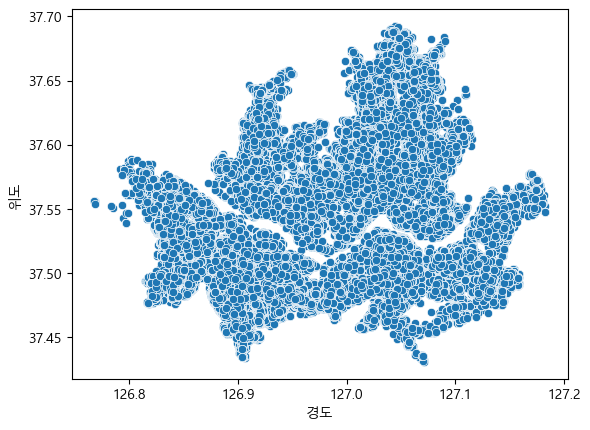

In [64]:
sns.scatterplot(data=df, x='경도', y='위도')

과제: 여러분이 서울시 상권에 대하여 알고 싶은 것은 무엇인가요?  (토론방에 제출)        
 > 우선 알고 싶은 것을 한가지만 적어보세요     
 > 먼저 여러분이 어떠한 방법으로 해결할 수 있을지 그 과정을 생각하고 한글로 적어봅니다            
 > AI 에 여러분이 알고 싶은 문제를 주고 코드를 받아 실행해봅니다          
 > 여러분이 그 코드를 보고 어디까지 익숙한 지 **어떠한 것이 새로운 지**에 대한 것을 토론방에 올립니다    
 > 매주 실습하고 있는 노트북 파일들은 **github** 에 잘 보관해두어야 합니다 (포트폴리오: 기말에 github 주소 제출)        
 > 이번 주 과제 : **AI 와 협업한 코드와 여러분이 알게 된 것** 을 적어 **토론방**에 올려주세요      
 > 토론방 활동을 통해 다른 친구들이 공부한 내용을 같이 공유해봅니다 

In [ ]:
Q. "서울시의 자치구 중에서 '약국'이 가장 많이 위치한 상위 5개 구는 어디인가?"

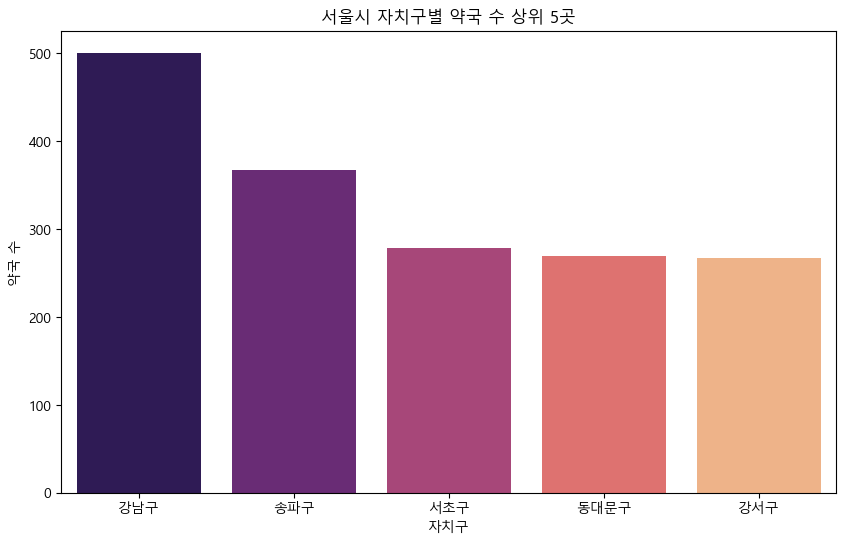

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 2. 데이터 불러오기
df = pd.read_csv('서울상권.csv', low_memory=False)

# 3. '약국' 데이터만 필터링
pharmacy_df = df[df['상권업종소분류명'] == '약국']

# 4. 구별로 개수 세고 상위 5개 추출
top5_pharmacy = pharmacy_df['시군구명'].value_counts().head(5)

# 5. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top5_pharmacy.index, 
    y=top5_pharmacy.values, 
    palette='magma', 
    hue=top5_pharmacy.index, 
    legend=False
)

plt.title('서울시 자치구별 약국 수 상위 5곳')
plt.xlabel('자치구')
plt.ylabel('약국 수')
plt.show()